# Основы NumPy: массивы и векторные вычисления



Numerical Python, или сокращенно NumPy, – один из важнейших пакетов для численных расчетов в Python. Во многих пакетах для научных расчетов используются объекты массивов NumPy, которые являются универсальным языком обмена данными. Значительная часть информации о NumPy, изложенной в этой части лекции, переносится и на pandas.

Благодаря наличию полного и хорошо документированного C API в NumPy очень легко передавать данные внешним библиотекам, написанным на языке низкого уровня, а также получать от внешних библиотек данные в виде массивов NumPy. Эта возможность сделала Python излюбленным языком для обертывания имеющегося кода на C, C++ и Fortran с приданием ему динамического и простого в использовании интерфейса.

Хотя сам по себе пакет NumPy почти не содержит средств для моделирования и научных расчетов, понимание массивов NumPy и ориентированных на эти массивы вычислений поможет гораздо эффективнее использовать инструменты типа pandas.



В большинстве приложений для анализа данных основной интерес представляет следующая функциональность:
* быстрые векторные операции для переформатирования и очистки данных, выборки подмножеств и фильтрации, преобразований и других видов вычислений;
* стандартные алгоритмы работы с массивами, удаление дубликатов и теоретико-множественные операции;
* эффективная описательная статистика, агрегирование и обобщение данных;
* выравнивание данных и реляционные операции объединения и соединения разнородных наборов данных;
* описание условной логики в виде выражений-массивов вместо циклов с ветвлением if-elif-else;
* групповые операции с данными (агрегирование, преобразование, применение функции).

Хотя в NumPy имеются вычислительные основы для этих операций, по большей части для анализа данных (особенно структурированных или табличных) лучше использовать библиотеку pandas, потому что она предлагает развитый высокоуровневый интерфейс для решения большинства типичных задач обработки данных – простой и лаконичный. Кроме того, в pandas есть кое-какая предметно-ориентированная функциональность, например операции с временными рядами, отсутствующая в NumPy.

Одна из причин,по которым NumPy играет такую важную роль в численных расчетах, – тот факт, что она проектировалась с прицелом на эффективную работу с большими массивами данных. Отметим, в частности, следующие аспекты:

* В NumPy сложные операции применяются к массивам целиком, так что отпадает необходимость в циклах for, которые для больших последовательностей могут работать медленно. NumPy быстрее кода на чистом Python, потому что в написанных на C алгоритмах нет накладных расходов, свойственных обычному интерпретируемому
Python-коду.
* NumPy хранит данные в непрерывном блоке памяти независимо от других встроенных объектов Python. Алгоритмы NumPy, написанные на языке C, могут работать с этим блоком, не обременяя себя про веркой типов и другими накладными расходами. Массивы NumPy потребляют гораздо меньше памяти, чем встроенные в Python последовательности.


Чтобы составить представление о выигрыше в производительности, рассмотрим массив NumPy, содержащий миллион чисел, и эквивалентный список Python:

In [45]:
import numpy as np
my_arr = np.arange(1_000_000)
my_list = list(range(1_000_000))

#Умножим каждую последовательность на 2:

%timeit my_arr2 = my_arr * 2

1.15 ms ± 23.7 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


Время выполнения этой операции составляет 1.28 миллисекунды (ms) с погрешностью ±56.1 микросекунды (µs) на один цикл.

In [46]:
%timeit my_map2 = map(lambda x: x*2, my_list)

185 ns ± 6.29 ns per loop (mean ± std. dev. of 7 runs, 1000000 loops each)


In [47]:
%timeit my_list2 = [x * 2 for x in my_list]

61.6 ms ± 13.4 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


Время выполнения этой операции составляет 121 миллисекунду (ms) с погрешностью ±13.2 миллисекунд на один цикл. Python обрабатывает списки поэлементно, что ведёт к более медленной производительности, особенно на больших объемах данных.

Алгоритмы, основанные на NumPy, в общем случае оказываются в 10–100 раз (а то и больше) быстрее аналогов, написанных на чистом Python, и потребляют гораздо меньше памяти.

# NumPy ndarray: объект многомерного массива

Одна из ключевых особенностей NumPy – объект ndarray для представления N-мерного массива; это быстрый и гибкий контейнер для хранения больших наборов данных в Python. Массивы позволяют выполнять математические операции над целыми блоками данных, применяя такой же синтаксис, как для соответствующих операций над скалярами.

Начнем с импорта NumPy и генерации небольшого массива случайных данных:

In [ ]:
import numpy as np

data = np.array([[1.5, -0.1, 3], [0, -3, 6.5]])
data

array([[ 1.5, -0.1,  3. ],
       [ 0. , -3. ,  6.5]])

Здесь и далее мы будем придерживаться стандартного соглашения NumPy и писать **import numpy as np.**

Можно было бы включать в код предложение from numpy import *, чтобы не писать каждый раз np., но я рекомендую не брать это в привычку. Пространство имен numpy очень велико и содержит ряд функций, имена которых совпадают с именами встроенных в Python функций (например, min и max). Соблюдать стандартные соглашения типа этого почти всегда имеет смысл.

Математические операции над data

In [ ]:
data * 10

array([[ 15.,  -1.,  30.],
       [  0., -30.,  65.]])

In [ ]:
data + data

array([[ 3. , -0.2,  6. ],
       [ 0. , -6. , 13. ]])

ndarray – это обобщенный многомерный контейнер для однородных данных, т. е. в нем могут храниться только элементы одного типа.

У любого массива есть атрибут shape – кортеж, описывающий размер по каждому измерению, и атрибут dtype – объект, описывающий тип данных в массиве:

In [ ]:
data.shape

(2, 3)

In [ ]:
data.dtype

dtype('float64')

**Создание ndarray**

Проще всего создать массив с помощью функции array. Она принимает любой объект, похожий на последовательность (в том числе другой массив), и порождает новый массив NumPy, содержащий переданные данные. Например, такое преобразование можно проделать со списком:

In [ ]:
data1 = [6, 7.5, 8, 0, 1]
arr1 = np.array(data1)
arr1

array([6. , 7.5, 8. , 0. , 1. ])

Вложенные последовательности, например список списков одинаковой длины, можно преобразовать в многомерный массив:

In [ ]:
data2 = [[1, 2, 3, 4], [5, 6, 7, 8]]
arr2 = np.array(data2)
arr2

array([[1, 2, 3, 4],
       [5, 6, 7, 8]])

Поскольку data2 – список списков, массив NumPy arr2 имеет два измерения, а его форма выведена из данных. В этом легко убедиться, прочитав атрибуты ndim и shape:

In [ ]:
arr2.ndim

2

In [ ]:
arr2.shape

(2, 4)

Если явно не задано иное (подробнее об этом ниже), то функция np.array пытается самостоятельно определить подходящий тип данных для создаваемого массива. Этот тип данных хранится в специальном объекте dtype

In [ ]:
arr1.dtype

dtype('float64')

In [ ]:
arr2.dtype

dtype('int64')

Помимо numpy.array, существует еще ряд функций для создания массивов. Например, numpy.zeros и numpy.ones создают массивы заданной длины или формы, состоящие из нулей и единиц соответственно, а numpy.empty создает массив, не инициализируя его элементы. Для создания многомерных массивов нужно передать кортеж, описывающий форму:

In [ ]:
np.zeros(10)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
np.zeros((3, 6))

array([[0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.]])

In [ ]:
np.empty((2, 3, 2))

array([[[4.82969186e-310, 0.00000000e+000],
        [0.00000000e+000, 0.00000000e+000],
        [0.00000000e+000, 0.00000000e+000]],

       [[0.00000000e+000, 0.00000000e+000],
        [0.00000000e+000, 0.00000000e+000],
        [0.00000000e+000, 0.00000000e+000]]])

Предполагать, что numpy.empty возвращает массив из одних нулей, небезопасно. Обычно возвращается массив, содержащий неинициализированный мусор, – как в примере выше, - любые значения, которые находились в памяти до этого.  

Эту функцию следует использовать, только если вы собираетесь заполнить новый массив данными.

Функция numpy.arange – вариант встроенной в Python функции range, только
возвращаемым значением является массив:

In [ ]:
np.arange(15)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

Функции np.full и np.full_like в NumPy используются для создания массивов с заданными значениями и размерами.

In [ ]:
np.full((3, 3), 0.5)

array([[0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5]])

Функция np.full_like создает новый массив с теми же размерами и типом данных, что и у заданного массива, и заполняет его указанным значением.

In [ ]:
x = np.zeros((5, 5))
full_like_array = np.full_like(x, 0.33)
full_like_array

array([[0.33, 0.33, 0.33, 0.33, 0.33],
       [0.33, 0.33, 0.33, 0.33, 0.33],
       [0.33, 0.33, 0.33, 0.33, 0.33],
       [0.33, 0.33, 0.33, 0.33, 0.33],
       [0.33, 0.33, 0.33, 0.33, 0.33]])

**Тип данных для ndarray**

Тип данных, или dtype, – это специальный объект, который содержит информацию, необходимую ndarray для интерпретации содержимого блока памяти

In [49]:
arr1 = np.array([1, 2, 3], dtype=np.float64)
arr2 = np.array([1, 2, 3])

arr1

array([1., 2., 3.])

In [51]:
arr2.dtype

dtype('int64')

Типам данных NumPy в значительной мере обязана своей эффективностью и гибкостью. В большинстве случаев они точно соответствуют внутреннему машинному представлению, что позволяет без труда читать и записывать двоичные потоки данных на диск, а также обмениваться данными с кодом, написанным на языке низкого уровня типа C или Fortran.

Числовые dtype именуются единообразно: имя типа, например float или int, затем число, указывающее разрядность одного элемента. Стандартное значение с плавающей точкой двойной точности (хранящееся во внутреннем представлении объекта Python типа float) занимает 8 байт или 64 бита. Поэтому соответствующий тип в NumPy называется float64.

Можно явно преобразовать, или привести, массив одного типа к другому, воспользовавшись методом astype:

In [52]:
arr = np.array([1, 2, 3, 4, 5])
arr.dtype

dtype('int64')

In [53]:
float_arr = arr.astype(np.float64)
float_arr

array([1., 2., 3., 4., 5.])

In [55]:
arr == float_arr

array([ True,  True,  True,  True,  True])

Здесь целые были приведены к типу с плавающей точкой. Если попытаться привести числа с плавающей точкой к целому типу, то дробная часть была бы отброшена:

In [56]:
arr = np.array([3.7, -1.2, -2.6, 0.7, 12.9, 10.1])
arr.astype(np.int32)

array([ 3, -1, -2,  0, 12, 10], dtype=int32)

Если имеется массив строк, представляющих целые числа, то astype позволит преобразовать их в числовую форму

In [60]:
numeric_strings = np.array(["1.25", "-9.6", "42"])
numeric_strings.astype(float)

array([ 1.25, -9.6 , 42.  ])

Если по какой-то причине выполнить приведение не удастся (например, если строку нельзя преобразовать в тип float64), то будет возбуждено исключение ValueError.

Кроме того, в примере выше мы написали float вместо np.float64, но NumPy оказалась достаточно «умной» – она умеет подменять типы Python эквивалентными собственными.

Будьте осторожнее при работе с типом numpy.string_, поскольку в NumPy размер строковых данных фиксирован и входные данные могут быть обрезаны без предупреждения. В pandas поведение  для нечисловых данных работает лучше.

Можно также использовать атрибут dtype другого массива:

In [ ]:
int_array = np.arange(10)
calibers = np.array([.22, .270, .357, .380, .44, .50], dtype=np.float64)

int_array.astype(calibers.dtype)

array([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.])

При вызове astype **всегда** создается новый массив (данные копируются), даже если новый dtype не отличается от старого.

**Арифметические операции с массивами NumPy**

Массивы важны, потому что позволяют выразить операции над совокупностями данных без выписывания циклов for. Обычно это называется векторизацией. Любая арифметическая операция над массивами одинакового размера применяется к соответственным элементам:

In [ ]:
arr = np.array([[1., 2., 3.], [4., 5., 6.]])
arr

array([[1., 2., 3.],
       [4., 5., 6.]])

In [ ]:
arr * arr

array([[ 1.,  4.,  9.],
       [16., 25., 36.]])

In [ ]:
arr - arr

array([[0., 0., 0.],
       [0., 0., 0.]])

Арифметические операции, в которых участвует скаляр, применяются к каждому элементу массива:

In [ ]:
1 / arr

array([[1.        , 0.5       , 0.33333333],
       [0.25      , 0.2       , 0.16666667]])

In [ ]:
arr ** 2

array([[ 1.,  4.,  9.],
       [16., 25., 36.]])

Сравнение массивов одинакового размера дает булев массив:

In [ ]:
arr2 = np.array([[0., 4., 1.], [7., 2., 12.]])
arr2 > arr

array([[False,  True, False],
       [ True, False,  True]])

**Индексирование и вырезание**


Индексирование массивов NumPy – обширная тема, поскольку подмножество массива или его отдельные элементы можно выбрать различными способами.

С одномерными массивами все просто; на поверхностный взгляд, они ведут себя как списки Python:

In [ ]:
arr = np.arange(10, 20)
arr

array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19])

In [ ]:
arr[5]

15

In [ ]:
arr[5:8]

array([15, 16, 17])

In [ ]:
arr[5:8] = 777
arr

array([ 10,  11,  12,  13,  14, 777, 777, 777,  18,  19])

Как видите, если присвоить скалярное значение срезу, как в arr[5:8] = 777, то оно распространяется на весь срез.

In [62]:
seq = [0, 1, 2, 3, 4, 5, 6]
seq[1:4] = [777]
seq

[0, 777, 4, 5, 6]

Важнейшее отличие от встроенных в Python списков состоит в том, что срез массива является представлением (ссылкой на часть) исходного массива. Это означает, что данные на самом деле не копируются, а любые изменения, внесенные в представление, попадают и в исходный массив.

In [66]:
arr

array([ 3.70e+00, -1.20e+00,  9.99e+02,  7.00e-01,  1.29e+01,  1.01e+01])

In [67]:
arr_slice = arr[1:4]
arr_slice

array([-1.20e+00,  9.99e+02,  7.00e-01])

In [69]:
arr_slice[1] = 999
arr

array([ 3.70e+00, -1.20e+00,  9.99e+02,  7.00e-01,  1.29e+01,  1.01e+01])

При первом знакомстве с NumPy это может стать неожиданностью, особенно если вы привыкли к программированию массивов в других языках, где копирование данных применяется чаще. Но NumPy проектировался для работы с большими массивами данных, поэтому при безудержном копировании данных неизбежно возникли бы проблемы с быстродействием и памятью.

Чтобы получить копию, а не представление среза массива, нужно выполнить операцию копирования явно, например new_arr = arr[5:8].copy(). Далее мы увидим, что pandas работает так же.

In [ ]:
new_arr = arr[4:8].copy()
new_arr

array([ 14, 777, 777, 777])

In [ ]:
new_arr[2] = 555
arr

array([ 10,  11, 999,  13,  14, 777, 777, 777,  18,  19])

In [ ]:
new_arr

array([ 14, 777, 555, 777])

**Индексирование трёхмерного массива**

In [ ]:
arr3d = np.array([[[1, 2, 3], [4, 5, 6]], [[7, 8, 9], [10, 11, 12]]])
arr3d

array([[[ 1,  2,  3],
        [ 4,  5,  6]],

       [[ 7,  8,  9],
        [10, 11, 12]]])

In [ ]:
arr3d.ndim

3

In [ ]:
arr3d.shape

(2, 2, 3)

In [ ]:
arr3d[0]

array([[1, 2, 3],
       [4, 5, 6]])

In [ ]:
arr3d[1]

array([[ 7,  8,  9],
       [10, 11, 12]])

**Индексирование срезами**

Как и для одномерных объектов наподобие списков Python, для объектов ndarray можно формировать срезы:

In [ ]:
arr = np.array([ 0, 1, 2, 3, 4, 64, 64, 64, 8, 9])
arr

array([ 0,  1,  2,  3,  4, 64, 64, 64,  8,  9])

In [ ]:
arr[1:6]

array([ 1,  2,  3,  4, 64])

Рассмотрим двумерный массив arr2d. Применение к нему вырезания дает результат:

In [ ]:
arr2d = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
arr2d

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [ ]:
arr2d[:2]

array([[1, 2, 3],
       [4, 5, 6]])

Можно указать несколько срезов – как несколько индексов:

In [ ]:
arr2d[:2, 1:]

array([[2, 3],
       [5, 6]])

При таком вырезании мы всегда получаем представления массивов с таким же числом измерений, как у исходного. Сочетая срезы и целочисленные индексы, можно получить массивы меньшей размерности.

Например, я могу выбрать вторую строку, а в ней только первые два столбца:

In [ ]:
lower_dim_slice = arr2d[1, :2]
lower_dim_slice

array([4, 5])

Аналогично я могу выбрать третий столбец, а в нем только первые две строки:

In [ ]:
arr2d[:2, 2]

array([3, 6])

Отметим, что двоеточие без указания числа означает, что нужно взять всю ось целиком, поэтому для вырезания только по осям высших размерностей можно поступить следующим образом:

In [ ]:
arr2d

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [ ]:
arr2d[:, :1]

array([[1],
       [4],
       [7]])

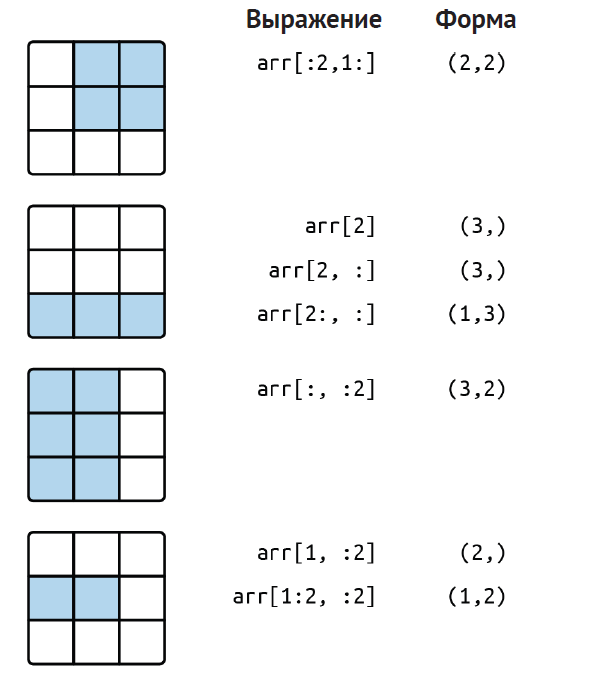

**Булево индексирование**

Пусть имеется некоторый массив с данными и массив имен, содержащий дубликаты:

In [ ]:
names = np.array(["Bob", "Joe", "Will", "Bob", "Will", "Joe", "Joe"])
data = np.array([[4, 7], [0, 2], [-5, 6], [0, 0], [1, 2],
        [-12, -4], [3, 4]])

data

array([[  4,   7],
       [  0,   2],
       [ -5,   6],
       [  0,   0],
       [  1,   2],
       [-12,  -4],
       [  3,   4]])

Допустим, что каждое имя соответствует строке в массиве data и мы хотим выбрать все строки, которым соответствует имя 'Bob'. Операции сравнения массивов (например, ==), как и арифметические, также векторизованы. Поэтому сравнение names со строкой 'Bob' дает массив булевых величин:

In [ ]:
names == "Bob"

array([ True, False, False,  True, False, False, False])

Этот булев массив можно использовать для индексирования другого массива:

In [ ]:
data[names == "Bob"]

array([[4, 7],
       [0, 0]])

Длина булева массива должна совпадать с длиной индексируемой им оси. Можно даже сочетать булевы массивы со срезами и целыми числами

In [ ]:
data[names == "Bob", 1:]

array([[7],
       [0]])

In [ ]:
data[names == "Bob", 0]

array([4, 0])

Оператор ~ пригодится, когда требуется инвертировать массив, адресуемый переменной:

In [ ]:
cond = names == "Bob"
data[~cond]

array([[  0,   2],
       [ -5,   6],
       [  1,   2],
       [-12,  -4],
       [  3,   4]])

Чтобы сформировать составное булево условие, включающее два из трех имен, воспользуемся булевыми операторами & (И) и | (ИЛИ):

In [ ]:
mask = (names == "Bob") | (names == "Will")
mask

array([ True, False,  True,  True,  True, False, False])

In [ ]:
data[mask]

array([[ 4,  7],
       [-5,  6],
       [ 0,  0],
       [ 1,  2]])

При выборке данных из массива путем булева индексирования **всегда** создается копия данных, даже если возвращенный массив совпадает с исходным.

Ключевые слова Python and и or с булевыми массивами **не работают**. Используйте вместо них & (и) и | (или).

Если значение устанавливается с применением булева массива, то значения из массива в правой части копируются в левую часть только тогда, когда значение соответствующего элемента булева массива равно True. Например, чтобы заменить все отрицательные значения в массиве data нулями, нужно всего лишь написать:



In [ ]:
data[data < 0] = 0
data

array([[4, 7],
       [0, 2],
       [0, 6],
       [0, 0],
       [1, 2],
       [0, 0],
       [3, 4]])

**Прихотливое индексирование**

Термином прихотливое индексирование (fancy indexing) в NumPy обозначается индексирование с помощью целочисленных массивов. Допустим, имеется массив 8×4:

In [ ]:
arr = np.zeros((8, 4))
for i in range(8):
    arr[i] = i
arr

array([[0., 0., 0., 0.],
       [1., 1., 1., 1.],
       [2., 2., 2., 2.],
       [3., 3., 3., 3.],
       [4., 4., 4., 4.],
       [5., 5., 5., 5.],
       [6., 6., 6., 6.],
       [7., 7., 7., 7.]])

Чтобы выбрать подмножество строк в определенном порядке, можно просто передать список или массив целых чисел, описывающих желаемый порядок:

In [ ]:
arr[[4, 3, 0, 6]]

array([[4., 4., 4., 4.],
       [3., 3., 3., 3.],
       [0., 0., 0., 0.],
       [6., 6., 6., 6.]])

При передаче нескольких массивов индексов делается несколько иное: выбирается одномерный массив элементов, соответствующих каждому кортежу индексов:

In [ ]:
arr = np.arange(32).reshape((8, 4))
arr

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23],
       [24, 25, 26, 27],
       [28, 29, 30, 31]])

In [ ]:
arr[[1, 5, 7, 2], [0, 3, 1, 2]]

array([ 4, 23, 29, 10])

Здесь отбираются элементы в позициях (1, 0), (5, 3), (7, 1) и (2, 2).

**Транспонирование и изменение формы**

Транспонирование – частный случай изменения формы, при этом также вращается представление исходных данных без какого-либо копирования.
У массивов имеется метод transpose и специальный атрибут T:

In [ ]:
arr = np.array([[1, 2, 3], [4, 5, 6]])

transposed_arr = arr.T

print("Исходный массив:")
print(arr)
print("\nТранспонированный массив:")
print(transposed_arr)

Исходный массив:
[[1 2 3]
 [4 5 6]]

Транспонированный массив:
[[1 4]
 [2 5]
 [3 6]]


Метод transpose используется для транспонирования массива, позволяя указать порядок осей.

In [ ]:
import numpy as np
arr = np.array([[1, 2, 3], [4, 5, 6]])
transposed_arr = np.transpose(arr, (1, 0))
print("Исходный массив:")
print(arr)
print("\nТранспонированный массив:")
print(transposed_arr)

Исходный массив:
[[1 2 3]
 [4 5 6]]

Транспонированный массив:
[[1 4]
 [2 5]
 [3 6]]


Метод reshape используется для изменения формы массива.

In [ ]:
arr = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

reshaped_arr = np.reshape(arr, (1, 9))

print("Исходный массив:")
print(arr)
print("\nМассив после изменения формы:")
print(reshaped_arr)

Исходный массив:
[[1 2 3]
 [4 5 6]
 [7 8 9]]

Массив после изменения формы:
[[1 2 3 4 5 6 7 8 9]]


Обычное транспонирование с помощью .T – частный случай перестановки осей. У объекта ndarray имеется метод swapaxes, который принимает пару номеров осей и меняет их местами, в результате чего данные реорганизуются:

In [ ]:
arr = np.array([[0, 1, 0], [1, 2, -2], [6, 3, 2], [-1, 0, -1], [1, 0, 1]])
arr

array([[ 0,  1,  0],
       [ 1,  2, -2],
       [ 6,  3,  2],
       [-1,  0, -1],
       [ 1,  0,  1]])

In [ ]:
arr.swapaxes(0, 1)

array([[ 0,  1,  6, -1,  1],
       [ 1,  2,  3,  0,  0],
       [ 0, -2,  2, -1,  1]])

Оси (axes) нумеруются с 0.
Для массива с n размерностями оси имеют номера от 0 до n-1.
Например:

* 1D массив (вектор) имеет одну ось: ось 0.
* 2D массив (матрица) имеет две оси: ось 0 (строки) и ось 1 (столбцы).
* 3D массив (тензор) имеет три оси: ось 0, ось 1, ось 2.

**Унарные универсальные функции**

Унарные универсальные функции в NumPy представляют собой функции, которые выполняют операции над отдельными элементами массивов. Они называются "унарными", потому что они оперируют только над одним операндом. Универсальные функции (universal functions, или ufuncs) в NumPy представляют собой векторизованные функции, что означает, что они могут применяться к массивам любой формы и размера, выполняя операцию над каждым элементом массива.

Эти функции обеспечивают быстрый и эффективный способ применения математических операций к элементам массива без необходимости использования явных циклов.

Основные унарные универсальные функции в NumPy:


In [ ]:
np.sum - вычисляет сумму всех элементов массива.
np.min - находит минимальный элемент массива.
np.max - находит максимальный элемент массива.
np.mean - вычисляет среднее арифметическое элементов массива.
np.std - вычисляет стандартное отклонение элементов массива.
np.var - вычисляет дисперсию элементов массива.
np.abs - вычисляет абсолютное значение каждого элемента массива.
np.sqrt - вычисляет квадратный корень каждого элемента массива.
np.log - вычисляет натуральный логарифм каждого элемента массива.
np.exp - вычисляет экспоненту каждого элемента массива.
np.sign - вычисляет знак каждого элемента массива. Возвращает -1 для отрицательных элементов, 0 для нулевых элементов и 1 для положительных элементов.
np.floor - округляет каждый элемент массива вниз до ближайшего целого числа.
np.isnan - проверяет, является ли элемент массива значением NaN (не числом). Возвращает True для элементов, которые являются NaN, и False для остальных.

In [ ]:
arr = np.array([[0, 1, 0], [1, np.nan, -2], [6, 3, 2], [np.nan, 0, -1], [1, 0, 1]])
arr[np.isnan(arr)] = 999
arr

array([[  0.,   1.,   0.],
       [  1., 999.,  -2.],
       [  6.,   3.,   2.],
       [ -1.,   0.,  -1.],
       [  1.,   0.,   1.]])

In [ ]:
arr_2d = np.array([[1, 2, 3],
                   [4, 5, 6]])

print("Сумма по axis=0 (по строкам):", np.sum(arr_2d, axis=0))
# [1+4, 2+5, 3+6] = [5, 7, 9]

Сумма по axis=0 (по строкам): [5 7 9]


In [ ]:
# Простой одномерный массив
arr_1d = np.array([3, 1, 4, 1, 5, 9, 2, 6, 5, 3])

# Минимум и максимум
min_val = np.min(arr_1d)
max_val = np.max(arr_1d)
print(min_val)
print(max_val)

1
9


In [ ]:
# Двумерный массив (матрица)
matrix = np.array([
    [5, 2, 8, 1],
    [3, 7, 4, 6],
    [9, 0, 2, 5]
])

print("Двумерный массив:")
print(matrix)

# Глобальный минимум и максимум во всей матрице
global_min = np.min(matrix)
global_max = np.max(matrix)

print(f"Глобальный минимум: {global_min}")  # 0
print(f"Глобальный максимум: {global_max}")  # 9

Двумерный массив:
[[5 2 8 1]
 [3 7 4 6]
 [9 0 2 5]]
Глобальный минимум: 0
Глобальный максимум: 9


In [ ]:
min_per_column = np.min(matrix, axis=0)
max_per_column = np.max(matrix, axis=0)

print("По столбцам (axis=0):")
print("Минимумы по столбцам:", min_per_column)
print("Максимумы по столбцам:", max_per_column)

# Минимумы и максимумы по строкам (axis=1)
min_per_row = np.min(matrix, axis=1)
max_per_row = np.max(matrix, axis=1)

print("По строкам (axis=1):")
print("Минимумы по строкам:", min_per_row)
print("Максимумы по строкам:", max_per_row)

По столбцам (axis=0):
Минимумы по столбцам: [3 0 2 1]
Максимумы по столбцам: [9 7 8 6]
По строкам (axis=1):
Минимумы по строкам: [1 3 0]
Максимумы по строкам: [8 7 9]


**Бинарные функции**

Бинарные функции (Binary Universal Functions (ufuncs)) в NumPy представляют собой функции, которые выполняют операции над парами элементов входных массивов:

In [ ]:
np.subtract - вычисляет разность элементов двух массивов.
np.multiply - вычисляет произведение элементов двух массивов.
np.divide - вычисляет частное элементов двух массивов.
np.logaddexp - вычисляет логарифм суммы экспонент элементов двух массивов.
np.logaddexp2 - вычисляет логарифм по основанию 2 от суммы экспонент элементов двух массивов.
np.true_divide - выполняет истинное деление элементов двух массивов.
np.floor_divide - выполняет целочисленное деление элементов двух массивов.
np.negative - вычисляет обратные элементы для каждого элемента массива.
np.power - возводит элементы первого массива в степень элементов второго массива.
np.remainder - вычисляет остаток от деления элементов двух массивов.
np.greater - сравнивает элементы двух массивов и возвращает массив, где элементы первого массива больше элементов второго массива.
np.less - сравнивает элементы двух массивов и возвращает массив, где элементы первого массива меньше элементов второго массива.
np.equal - сравнивает элементы двух массивов и возвращает массив, где элементы равны.
np.not_equal - сравнивает элементы двух массивов и возвращает массив, где элементы не равны.

**Запись логических условий в виде операций с массивами**

Запись логических условий в виде операций с массивами — это способ применения логических условий к элементам массивов в NumPy. Это позволяет создавать новые массивы на основе значений других массивов, используя функцию np.where.

np.where — это функция библиотеки NumPy в Python, предназначенная для выполнения условного элементарного поэлементного выбора значений из двух массивов в зависимости от заданного условия. Она имеет несколько форм синтаксиса, основные из которых выглядят следующим образом:

numpy.where(condition[x, y])

* condition: Логическое выражение или массив булевых значений. Если condition равно True, то соответствующее значение из x выбирается, в противном случае - из y.
* x: Значение или массив, используемый при условии True.
* y: Значение или массив, используемый при условии False.

Примеры использования:

In [ ]:
# Простой выбор между двумя значениями:

x = np.array([1, 2, 3, 4, 5])
y = np.where(x > 3, 'больше трех', 'три и меньше')
print(y)

['три и меньше' 'три и меньше' 'три и меньше' 'больше трех' 'больше трех']


In [ ]:
# Замена значений в массиве:

x = np.array([1, 2, 3, 4, 5])
y = np.where(x % 2 == 0, 'четное', 'нечетное')
print(y)
# ['нечетное' 'четное' 'нечетное' 'четное' 'нечетное']

['нечетное' 'четное' 'нечетное' 'четное' 'нечетное']


In [ ]:
# Использование без явного указания y:

x = np.array([[1, 2, 3, 4, 5], [2, 2, 3, 4, 5]])
print(x)
y = np.where(x > 2)
print(y)

# В этом случае, если x > 2, возвращается ИНДЕКС тех элементов, где условие истинно.

[[1 2 3 4 5]
 [2 2 3 4 5]]
(array([0, 0, 0, 1, 1, 1]), array([2, 3, 4, 2, 3, 4]))


**Математические и статистические операции с массивами**

Математические и статистические операции с массивами в библиотеке NumPy включают в себя различные функции, позволяющие проводить вычисления с элементами массивов. Эти операции обеспечивают мощные инструменты для анализа данных, научных вычислений и многих других приложений. Вот некоторые из ключевых операций:

In [ ]:
np.median - вычисляет медиану элементов массива.
np.std - вычисляет стандартное отклонение элементов массива.
np.var - вычисляет дисперсию элементов массива.
np.cumsum - вычисляет кумулятивную сумму элементов массива.
np.cumprod - вычисляет кумулятивное произведение элементов массива.
np.ptp - вычисляет разницу между максимальным и минимальным элементами массива.
np.diff - вычисляет разность между соседними элементами массива.
np.bincount(arr) - подсчитывает количество вхождений каждого уникального значения в массиве arr.

**Сортировка, удаление дубликатов и другие операции**

Эти функции также являются частью библиотеки NumPy и предоставляют операции для работы с множествами или уникальными элементами массивов:

In [ ]:
np.sort(a, axis=-1, kind=None, order=None)

Описание: Функция np.sort сортирует элементы массива a вдоль указанной оси axis (по умолчанию -1, что означает последнюю ось).

Параметры:
a: Массив для сортировки.
axis (по умолчанию -1): Ось, вдоль которой будет производиться сортировка.
kind (по умолчанию None): Метод сортировки. Возможные значения: 'quicksort', 'mergesort', 'heapsort'.
order (по умолчанию None): Порядок сортировки. Может быть функцией или списком функций, которые определяют порядок элементов.

Возвращаемое значение: Сортированный массив.

In [ ]:
x = np.array([[7, 2, 8, 4, 5], [2, 8, 1, 4, 5]])
x

array([[7, 2, 8, 4, 5],
       [2, 8, 1, 4, 5]])

In [ ]:
np.sort(x, axis=-1, kind=None, order=None)

array([[2, 4, 5, 7, 8],
       [1, 2, 4, 5, 8]])

In [70]:
import numpy as np

# Определяем тип данных с полями
dtype = [
    ('name', 'U10'),      # Unicode строка до 10 символов
    ('age', 'i4'),        # 32-битное целое
    ('salary', 'f8'),     # 64-битное число с плавающей точкой
    ('department', 'U5')  # Unicode строка до 5 символов
]

# Создаем данные
employees = np.array([
    ('Alice', 28, 55000.0, 'IT'),
    ('Bob', 25, 60000.0, 'HR'),
    ('Charlie', 30, 50000.0, 'IT'),
    ('Diana', 28, 65000.0, 'FIN'),
    ('Eve', 25, 45000.0, 'HR')
], dtype=dtype)

print("Исходные данные:")
print(employees)

Исходные данные:
[('Alice', 28, 55000., 'IT') ('Bob', 25, 60000., 'HR')
 ('Charlie', 30, 50000., 'IT') ('Diana', 28, 65000., 'FIN')
 ('Eve', 25, 45000., 'HR')]


In [ ]:
employees.dtype

dtype([('name', '<U10'), ('age', '<i4'), ('salary', '<f8'), ('department', '<U5')])

In [71]:
# Сортировка по возрасту
sorted_by_age = np.sort(employees, order='age')
print("Сортировка по возрасту:")
print(sorted_by_age)

# Сортировка по зарплате
sorted_by_salary = np.sort(employees, order='salary')
print("\nСортировка по зарплате:")
print(sorted_by_salary)

Сортировка по возрасту:
[('Bob', 25, 60000., 'HR') ('Eve', 25, 45000., 'HR')
 ('Alice', 28, 55000., 'IT') ('Diana', 28, 65000., 'FIN')
 ('Charlie', 30, 50000., 'IT')]

Сортировка по зарплате:
[('Eve', 25, 45000., 'HR') ('Charlie', 30, 50000., 'IT')
 ('Alice', 28, 55000., 'IT') ('Bob', 25, 60000., 'HR')
 ('Diana', 28, 65000., 'FIN')]


In [ ]:
np.unique(ar, return_index=False, return_inverse=False, return_counts=False, axis=None)

Описание: Функция np.unique возвращает уникальные элементы массива ar и их количество.

Параметры:
ar: Массив для обработки.
return_index (по умолчанию False): Если True, возвращает индексы уникальных элементов.
return_inverse (по умолчанию False): Если True, возвращает инвертированный массив, где уникальные элементы заменены на их индексы.
return_counts (по умолчанию False): Если True, возвращает количество каждого уникального элемента.
axis (по умолчанию None): Ось, вдоль которой будет производиться поиск уникальных элементов.

Возвращаемое значение:
Уникальные элементы массива.
Индексы уникальных элементов (если return_index True).
Инвертированный массив (если return_inverse True).
Количество каждого уникального элемента (если return_counts True).

In [ ]:
# Простой массив с повторениями
data = np.array([1, 2, 2, 3, 3, 3, 4, 4, 4, 4])
unique_vals = np.unique(data)
print("Уникальные значения:", unique_vals)

# Работа со строками
words = np.array(['apple', 'banana', 'apple', 'cherry', 'banana'])
unique_words = np.unique(words)
print("Уникальные слова:", unique_words)

Уникальные значения: [1 2 3 4]
Уникальные слова: ['apple' 'banana' 'cherry']


In [ ]:
# Двумерный массив
matrix = np.array([
    [1, 2, 3],
    [2, 3, 4],
    [1, 2, 3],
    [3, 4, 5]
])

print("Исходная матрица:")
print(matrix)

# Уникальные строки
unique_rows = np.unique(matrix, axis=0)
print("\nУникальные строки:")
print(unique_rows)

# Уникальные столбцы
unique_cols = np.unique(matrix, axis=1)
print("\nУникальные столбцы:")
print(unique_cols)

Исходная матрица:
[[1 2 3]
 [2 3 4]
 [1 2 3]
 [3 4 5]]

Уникальные строки:
[[1 2 3]
 [2 3 4]
 [3 4 5]]

Уникальные столбцы:
[[1 2 3]
 [2 3 4]
 [1 2 3]
 [3 4 5]]


In [ ]:
np.delete(arr, obj, axis=None)

Описание: Функция np.delete удаляет указанные элементы из массива arr.

Параметры:
arr: Массив для обработки.
obj: Элементы, которые нужно удалить.
axis (по умолчанию None): Ось, вдоль которой будут удалены элементы.

Возвращаемое значение:
Массив с удаленными элементами.
Важно помнить, что она возвращает новый массив и не изменяет исходный.

In [ ]:
# Удаление одного элемента
arr = np.array([1, 2, 3, 4, 5])
result = np.delete(arr, 2)  # Удаляем элемент с индексом 2
print("Исходный массив:", arr)
print("После удаления элемента с индексом 2:", result)

# Удаление нескольких элементов по индексам
arr = np.array([10, 20, 30, 40, 50, 60])
result = np.delete(arr, [1, 3, 4])  # Удаляем элементы с индексами 1, 3, 4
print("После удаления индексов [1, 3, 4]:", result)

Исходный массив: [1 2 3 4 5]
После удаления элемента с индексом 2: [1 2 4 5]
После удаления индексов [1, 3, 4]: [10 30 60]


In [ ]:
# Двумерный массив
matrix = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

print("Исходная матрица:")
print(matrix)

# Удаление строки
without_row_1 = np.delete(matrix, 1, axis=0)  # Удаляем строку с индексом 1
print("\nПосле удаления строки 1:")
print(without_row_1)

# Удаление столбца
without_col_0 = np.delete(matrix, 0, axis=1)  # Удаляем столбец с индексом 0
print("\nПосле удаления столбца 0:")
print(without_col_0)

Исходная матрица:
[[1 2 3]
 [4 5 6]
 [7 8 9]]

После удаления строки 1:
[[1 2 3]
 [7 8 9]]

После удаления столбца 0:
[[2 3]
 [5 6]
 [8 9]]


In [ ]:
numpy.intersect1d(ar1, ar2, assume_unique=False, return_indices=False)

Описание: Функция numpy.intersect1d возвращает общие элементы двух массивов ar1 и ar2.

Параметры:
ar1: Первый массив.
ar2: Второй массив.
assume_unique (по умолчанию False): Если True, предполагается, что массивы содержат уникальные элементы.
return_indices (по умолчанию False): Если True, возвращает индексы общих элементов в обоих массивах.

Возвращаемое значение:
Общие элементы массивов ar1 и ar2.
Индексы общих элементов (если return_indicesTrue).

In [ ]:
np.union1d(ar1, ar2)

Описание: Функция np.union1d возвращает объединение элементов двух массивов ar1 и ar2.

Параметры:
ar1: Первый массив.
ar2: Второй массив.

Возвращаемое значение:
Объединение элементов массивов ar1 и ar2.

In [ ]:
np.in1d(ar1, ar2, assume_unique=False, invert=False)

Описание: Функция np.in1d проверяет, находятся ли элементы массива ar1 в массиве ar2.

Параметры:
ar1: Первый массив.
ar2: Второй массив.
assume_unique (по умолчанию False): Если True, предполагается, что массивы содержат уникальные элементы.
invert (по умолчанию False): Если True, возвращает инвертированный результат, то есть элементы, которые не находятся в ar2.

Возвращаемое значение:
Массив логических значений, указывающих, находятся ли элементы ar1 в ar2.
Инвертированный массив логических значений (если invertTrue).

In [ ]:
np.setdiff1d(ar1, ar2, assume_unique=False)

Описание: Функция np.setdiff1d возвращает элементы массива ar1, которые не находятся в массиве ar2.

Параметры:
ar1: Первый массив.
ar2: Второй массив.
assume_unique (по умолчанию False): Если True, предполагается, что массивы содержат уникальные элементы.

Возвращаемое значение:
Элементы массива ar1, которые не находятся в ar2.

In [ ]:
np.setxor1d(ar1, ar2, assume_unique=False)

Описание: Функция np.setxor1d возвращает элементы, которые находятся в одном из массивов ar1 или ar2, но не в обоих.

Параметры:
ar1: Первый массив.
ar2: Второй массив.
assume_unique (по умолчанию False): Если True, предполагается, что массивы содержат уникальные элементы.

Возвращаемое значение:
Элементы, которые находятся в одном из массивов ar1 или ar2, но не в обоих.

**Генерирование псевдослучайных чисел**

Модуль numpy.random дополняет встроенный модуль random функциями, которые генерируют целые массивы случайных чисел с различными распределениями вероятности. Например, с помощью функции numpy.random.standard_normal можно получить случайный массив 4×4, выбранный из стандартного нормального распределения:

In [ ]:
samples = np.random.standard_normal(size=(4, 4))
samples

array([[-0.63601235, -0.00639013, -0.959999  ,  2.0750566 ],
       [ 0.57818339, -0.37748915, -0.75880508, -0.32848173],
       [-0.72747623,  0.54710236,  1.1388779 ,  1.02064159],
       [ 1.52839687,  1.97535934,  0.56743038, -0.69727588]])

Встроенный в Python модуль random умеет выдавать только по одному случайному числу за одно обращение. numpy.random более чем на порядок быстрее стандартного модуля при генерации очень больших выборок.